In [36]:
import sys
sys.path.insert(0, '/code/src')

import pandas as pd 
import numpy as np
from datetime import datetime, date
import seaborn as sns
import pynwb
from matplotlib import pyplot as plt
import time
from tqdm.auto import tqdm

import importlib
import module
importlib.reload(module)
from module import decode_trial_identity

from sklearn.svm import LinearSVC
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import confusion_matrix

In [37]:
# ---------------------------------------------------------------------------
# Shared colour scheme (teal / orange / purple) used by every figure below.
# Change these three hex values to restyle the whole notebook at once.
import matplotlib as mpl

C_TEAL   = "#48A69C"
C_ORANGE = "#E78C3B"
C_PURPLE = "#7D57C1"
C_GREY   = "#333333"

# task-context block -> colour (aud = purple, vis = teal)
BLOCK_PAL = {'aud': C_PURPLE, 'vis': C_TEAL}
BLOCK_ORDER = ['aud', 'vis']

# feature-importance groups in the error-vs-stim comparison
GROUP_PAL = {'error_exclusive': C_ORANGE, 'stim_exclusive': C_TEAL,
             'shared': C_PURPLE, 'other': '0.8'}

# white -> purple sequential map for heatmaps (confusion matrices)
SEQ_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    'seq_purple', ['#ffffff', C_PURPLE])

# default line / marker colour cycle
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=[C_TEAL, C_ORANGE, C_PURPLE])


In [38]:
from aind_data_access_api.document_db import MetadataDbClient

API_GATEWAY_HOST = "api.allenneuraldynamics.org"
DATABASE = 'metadata_index'
COLLECTION = 'data_assets'

docdb_api_client = MetadataDbClient(
   host=API_GATEWAY_HOST,
    version="v2",
   database=DATABASE,
   collection=COLLECTION,
)
print(docdb_api_client._base_url)

https://api.allenneuraldynamics.org/v2/metadata_index/data_assets


In [39]:
aggregate = [
  {
    "$match": {
      "data_description.project_name": "Dynamic Routing", 
      "data_description.data_level": "derived", 
      "processing.data_processes": {
        "$elemMatch": {
          "process_type": "File format conversion",
          "start_date_time": {"$regex": "^2026-08-04"}
        }
      }
    }
  },
  {
    "$project": {
      "name": 1, 
      "subject_id": "$data_description.subject_id",
      "genotype": "$subject.subject_details.genotype", 
      "date_of_birth": "$subject.subject_details.date_of_birth", 
      "sex": "$subject.subject_details.sex",  
      "session_start_time": "$acquisition.acquisition_start_time",
      "session_end_time": "$acquisition.acquisition_end_time", 
      "stimulus_epochs": "$acquisition.stimulus_epochs",
      "project_name": "$data_description.project_name", 
      "modality": "$data_description.modalities.name", 
      "targeted_structure": "$acquisition.data_streams.configurations.probes.primary_targeted_structure.name" 
    }
  },
]
    
records = docdb_api_client.aggregate_docdb_records(pipeline=aggregate)

# Extract performance metrics in Python
for r in records:
    dr = next((e for e in r.get("stimulus_epochs", []) if e.get("stimulus_name") == "DynamicRouting1"), None)
    r["dr_performance"] = dr["performance_metrics"] if dr else None

In [40]:
df = pd.DataFrame(records)
df['session_date'] = df.apply(lambda x: datetime.fromisoformat(x['session_start_time']).date(), axis=1)
df['session_start_time'] = df.apply(lambda x: datetime.fromisoformat(x['session_start_time']).time(), axis=1)
df['session_end_time'] = df.apply(lambda x: datetime.fromisoformat(x['session_end_time']).time(), axis=1)
df['date_of_birth'] = df.apply(lambda x: datetime.strptime(x['date_of_birth'], '%Y-%m-%d').date(), axis=1)
df['age'] = df.apply(lambda x: (x['session_date'] - x['date_of_birth']).days, axis=1)

df['trials_total'] = df['dr_performance'].apply(lambda x: x['trials_total'] if x else None)
df['trials_rewarded'] = df['dr_performance'].apply(lambda x: x['trials_rewarded'] if x else None)
df['reward_rate'] = df['trials_rewarded'] / df['trials_total']
df['reward_consumed_mL'] = df['dr_performance'].apply(lambda x: x['reward_consumed_during_epoch'] if x else None)
df['block_metrics'] = df['dr_performance'].apply(lambda x: x['output_parameters']['block_metrics'] if x else None)
df['mean_dprime_same_modal'] = df['block_metrics'].apply(
    lambda x: pd.Series([b['dprime_same_modal'] for b in x.values()]).mean() if x else None
)
df['mean_dprime_other_modal'] = df['block_metrics'].apply(
    lambda x: pd.Series([b['dprime_other_modal_go'] for b in x.values()]).mean() if x else None
)

order = ['project_name', '_id', 'name', 'subject_id', 'genotype', 'date_of_birth', 'age', 'sex',
         'modality', 'session_date', 'session_start_time', 'session_end_time', 'targeted_structure',
         'trials_total', 'trials_rewarded', 'reward_rate', 'reward_consumed_mL',
         'mean_dprime_same_modal', 'mean_dprime_other_modal']
df = df[order].sort_values(by='subject_id')

In [41]:
# --- Pass 1: scan every mouse x region for the decoding criterion ----------
# Four decoders, each run within a single task block:
#
#   error decoder  -> block TARGET-stimulus HIT  vs  block DISTRACTOR FALSE ALARM
#                     aud block: sound1 hit  vs  vis1  false alarm
#                     vis block: vis1  hit  vs  sound1 false alarm
#                     (stimulus identity is confounded with the lick / error
#                      signal -- that is the point of the comparison below)
#
#   stim  decoder  -> sound2 vs vis2 on CORRECT-REJECT trials (licking correctly
#                     withheld), so it reads stimulus identity only and is not
#                     confounded by the lick / error signal
#
# Both decoders are run separately in the auditory block and in the visual
# block, giving four decoders total: error_aud, error_vis, stim_aud, stim_vis.
#
# A region-session qualifies for a decoder if it has >= MIN_UNITS QC units and
# >= MIN_TRIALS_PER_CLASS trials in each of that decoder's two classes.
#
# The datacube is a read-only FUSE mount, so an individual chunk read can fail
# with OSError (Errno 5) even though the path exists. Each session load is
# retried; a session whose data stays unreadable is skipped and recorded in
# `failed_sessions` instead of aborting the whole scan.

from module import get_stim_times, _BLOCK_STIM

MIN_UNITS = 50
MIN_TRIALS_PER_CLASS = 10
MIN_SESSIONS = 3          # keep regions meeting criterion in >= 3 sessions

N_LOAD_RETRIES = 1        # attempts per session before giving up on it
LOAD_RETRY_WAIT = 10      # seconds between attempts

# name -> (stim_a, outcome_a, stim_b, outcome_b, block)
DECODER_TRIALS = {
    'error_aud': ('sound1', 'is_hit',            'vis1',   'is_false_alarm',    'aud'),
    'error_vis': ('vis1',   'is_hit',            'sound1', 'is_false_alarm',    'vis'),
    'stim_aud':  ('sound2', 'is_correct_reject', 'vis2',   'is_correct_reject', 'aud'),
    'stim_vis':  ('sound2', 'is_correct_reject', 'vis2',   'is_correct_reject', 'vis'),
}


def load_session(nwb_path, n_retries=N_LOAD_RETRIES, wait=LOAD_RETRY_WAIT):
    """Read one session, retrying failed reads from the datacube mount.

    Returns (nwbfile, units_df, trials_df), or None if every attempt failed.
    Both tables are materialised here so that a chunk the mount cannot serve
    fails now, on a session we can skip, rather than later inside Pass 2.
    """
    for attempt in range(1, n_retries + 1):
        try:
            nwbfile = pynwb.read_nwb(nwb_path)
            return nwbfile, nwbfile.units.to_dataframe(), nwbfile.trials.to_dataframe()
        except OSError as err:
            tqdm.write(f"  read failed (attempt {attempt}/{n_retries}): {err}")
            if attempt < n_retries:
                time.sleep(wait)
    return None


nwb_cache = {}            # subject_id -> (nwbfile, units_df, trials_df), reused in Pass 2
failed_sessions = []      # sessions the mount would not serve
scan_rows = []
for _, m in tqdm(list(df.iterrows()), desc="scan", unit="mouse"):
    nwb_path = f"/data/dynamicrouting_datacube/{m['name']}/{m['name'][8:25]}.nwb.zarr"
    t0 = time.time()
    loaded = load_session(nwb_path)
    if loaded is None:
        failed_sessions.append(dict(mouse_id=m['subject_id'], name=m['name']))
        tqdm.write(f"{m['subject_id']}: SKIPPED -- unreadable after "
                   f"{N_LOAD_RETRIES} attempts ({time.time() - t0:.0f}s)")
        continue
    nwbfile, units, trials = loaded
    nwb_cache[m['subject_id']] = (nwbfile, units, trials)

    # trials per class for each decoder (block match is on by default)
    trial_counts = {}
    for name, (sa, oa, sb, ob, blk) in DECODER_TRIALS.items():
        na = int(get_stim_times(trials, sa, blk, oa).sum())
        nb = int(get_stim_times(trials, sb, blk, ob).sum())
        trial_counts[name] = (na, nb)

    unit_counts = units.loc[units.default_qc, 'structure'].value_counts()
    for region, n_units in unit_counts.items():
        units_ok = n_units >= MIN_UNITS
        row = dict(mouse_id=m['subject_id'], region=region, n_units=int(n_units))
        for name, (na, nb) in trial_counts.items():
            row[f'n_{name}_a'] = na
            row[f'n_{name}_b'] = nb
            row[f'meets_{name}'] = bool(units_ok
                                       and na >= MIN_TRIALS_PER_CLASS
                                       and nb >= MIN_TRIALS_PER_CLASS)
        scan_rows.append(row)
    tqdm.write(f"{m['subject_id']}: "
               + " | ".join(f"{k} {v[0]}/{v[1]}" for k, v in trial_counts.items())
               + f"  ({time.time() - t0:.0f}s to load)")

scan = pd.DataFrame(scan_rows)

if failed_sessions:
    print(f"\n!! {len(failed_sessions)} of {len(df)} sessions skipped as unreadable: "
          + ", ".join(f['mouse_id'] for f in failed_sessions))
print(f"scanned {scan.mouse_id.nunique()} sessions, "
      f"{scan.region.nunique()} distinct regions\n")

def _keep(col):
    counts = scan[scan[col]].groupby('region').mouse_id.nunique()
    return sorted(counts[counts >= MIN_SESSIONS].index)

# regions meeting each decoder's criterion in >= MIN_SESSIONS sessions
keep = {name: _keep(f'meets_{name}') for name in DECODER_TRIALS}
for name, regions in keep.items():
    print(f"{name:<10}: {len(regions):2d} regions in >= {MIN_SESSIONS} sessions: {regions}")


scan:   0%|          | 0/12 [00:00<?, ?mouse/s]/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (430361, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (430350, 500) float32 read-only>
  warnings.warn(
scan:   0%|          | 0/12 [00:20<?, ?mouse/s]


KeyboardInterrupt: 

## Choosing the decoding window — trial-averaged population PSTH

Before decoding, look at the grand-average peri-stimulus firing of every
default-QC unit in every loaded session, aligned to stimulus onset and
averaged over all target trials. Each unit is baseline-subtracted (mean rate
in the 0.3 s before onset) so the sensory transient is not swamped by a few
high-rate units.

Overlaid are the mean **first-lick latency** (`trials.response_time` −
stimulus onset, over target trials with a response) and the mean **reward
latency** (`trials.reward_time` − stimulus onset, over rewarded trials), each
with a ±1 SD band across trials pooled over sessions.

The shaded band is the current decoding window (`DECODE_WINDOW_S`). Move it so
it sits **after the main sensory response but before the first licks / reward**,
then re-run Pass 2 — `DECODE_BIN_EDGES` / `WINDOW_BIN_SLICE` defined here are
what Pass 2 (and the pooled decoder) use.

In [ ]:
# Trial-averaged population PSTH + behavioural event times -> pick the window.
from module import get_binned_triggered_spike_counts_fast

# --- decoding window, shared by Pass 2 and the pooled decoder -------------
DECODE_BIN_EDGES = np.arange(-0.3, 2.0, 0.1)      # 100 ms bins, relative to onset
DECODE_WINDOW_S = (0.0, 0.6)                      # <-- decoding window (s from onset); tune from the plot
_lo = int(np.argmin(np.abs(DECODE_BIN_EDGES - DECODE_WINDOW_S[0])))
_hi = int(np.argmin(np.abs(DECODE_BIN_EDGES - DECODE_WINDOW_S[1])))
WINDOW_BIN_SLICE = slice(_lo, _hi)
print(f"decode window {DECODE_WINDOW_S[0]:.2f}-{DECODE_WINDOW_S[1]:.2f} s "
      f"-> bins {WINDOW_BIN_SLICE.start}:{WINDOW_BIN_SLICE.stop}")

# --- PSTH settings ------------------------------------------------------
PSTH_EDGES = np.arange(-0.5, 1.5 + 1e-9, 0.02)    # 20 ms bins for the display
PSTH_CENTERS = PSTH_EDGES[:-1] + np.diff(PSTH_EDGES) / 2
BASELINE_S = (-0.3, 0.0)
_base_mask = (PSTH_CENTERS >= BASELINE_S[0]) & (PSTH_CENTERS < BASELINE_S[1])

unit_psth_rows = []          # baseline-subtracted rate, one row per QC unit
lick_latency_all, reward_latency_all = [], []
for subject_id, (_nwb, units_s, trials_s) in nwb_cache.items():
    onset = trials_s.stim_start_time.to_numpy()
    is_tgt = trials_s.is_target.to_numpy()
    tgt_onset = onset[is_tgt]
    qc = units_s[units_s.default_qc]
    for spike_times in qc.spike_times.values:
        counts = get_binned_triggered_spike_counts_fast(
            spike_times, tgt_onset, PSTH_EDGES)
        rate = counts.mean(axis=0) / np.diff(PSTH_EDGES)
        unit_psth_rows.append(rate - rate[_base_mask].mean())

    lick = trials_s.response_time.to_numpy() - onset
    lick_latency_all.append(lick[is_tgt & trials_s.is_response.to_numpy()
                                 & np.isfinite(lick)])
    rew = trials_s.reward_time.to_numpy() - onset
    reward_latency_all.append(rew[trials_s.is_rewarded.to_numpy() & np.isfinite(rew)])

psth_mat = np.vstack(unit_psth_rows)
grand = psth_mat.mean(axis=0)
grand_sem = psth_mat.std(axis=0, ddof=1) / np.sqrt(psth_mat.shape[0])
lat_lick = np.concatenate(lick_latency_all)
lat_reward = np.concatenate(reward_latency_all)

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.axhline(0, color='0.7', lw=0.8)
ax.axvspan(*DECODE_WINDOW_S, color='0.85', alpha=0.7, zorder=0,
           label=f'decode window {DECODE_WINDOW_S[0]:.2f}-{DECODE_WINDOW_S[1]:.2f} s')
ax.fill_between(PSTH_CENTERS, grand - grand_sem, grand + grand_sem,
                color=C_PURPLE, alpha=0.25)
ax.plot(PSTH_CENTERS, grand, color=C_PURPLE, lw=2,
        label=f'grand-average PSTH (n={psth_mat.shape[0]} units)')
for lat, colour, lab in [(lat_lick, C_ORANGE, 'first lick'),
                         (lat_reward, C_TEAL, 'reward')]:
    m, s = np.nanmean(lat), np.nanstd(lat)
    ax.axvspan(m - s, m + s, color=colour, alpha=0.12)
    ax.axvline(m, color=colour, lw=2, label=f'mean {lab} = {m:.2f} s (n={lat.size})')
ax.set_xlabel('time from stimulus onset (s)')
ax.set_ylabel('baseline-subtracted firing rate (Hz)')
ax.set_title('trial-averaged population PSTH — all default-QC units, all sessions')
ax.legend(frameon=False, fontsize=9)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


In [ ]:
# --- Pass 2: run all four decoders on their kept region-sessions ----------
# Reuses the nwbfiles cached in Pass 1. Each region-session is decoded with a
# 50-unit / 10-trial-per-class subsample so feature count and sample count are
# matched across regions, blocks and decoders.
#
# chance is estimated empirically per region-session (label shuffle, N_PERM
# permutations of the same cross-validation). Feature importance comes from
# N_IMPORTANCE_REPEATS independent stratified train/test splits.
N_PERM = 200
N_IMPORTANCE_REPEATS = 10
IMPORTANCE_TOP_FRAC = 0.10     # flag the top 10% of neurons by |w_r| each repeat

DECODERS = {
    'error_aud': dict(family='error', block='aud',
                      kwargs=dict(block='aud', outcome_filter=1, match_block=True)),
    'error_vis': dict(family='error', block='vis',
                      kwargs=dict(block='vis', outcome_filter=1, match_block=True)),
    'stim_aud':  dict(family='stim', block='aud',
                      kwargs=dict(block='aud', stim_pair=('sound2', 'vis2'),
                                  class_outcomes=('is_correct_reject', 'is_correct_reject'),
                                  match_block=True)),
    'stim_vis':  dict(family='stim', block='vis',
                      kwargs=dict(block='vis', stim_pair=('sound2', 'vis2'),
                                  class_outcomes=('is_correct_reject', 'is_correct_reject'),
                                  match_block=True)),
}

rows = []
for name, spec in DECODERS.items():
    todo = scan[scan[f'meets_{name}'] & scan.region.isin(keep[name])]
    print(f"[{name}] decoding {len(todo)} region-sessions "
          f"({todo.mouse_id.nunique()} mice, {todo.region.nunique()} regions)")
    for subject_id, grp in tqdm(todo.groupby('mouse_id'), desc=name, unit="mouse"):
        nwbfile, _, _ = nwb_cache[subject_id]
        for region in tqdm(sorted(grp.region), desc=f"{subject_id}",
                           unit="region", leave=False):
            r = decode_trial_identity(
                nwbfile, region,
                decode_bin_edge_array=DECODE_BIN_EDGES,
                window_bin_slice=WINDOW_BIN_SLICE,  # set from the PSTH cell (DECODE_WINDOW_S)
                n_neurons=50, n_trials=10,
                min_units=MIN_UNITS, min_trials_per_class=MIN_TRIALS_PER_CLASS,
                n_permutations=N_PERM,
                n_importance_repeats=N_IMPORTANCE_REPEATS,
                importance_top_frac=IMPORTANCE_TOP_FRAC,
                mouse_id=subject_id,
                **spec['kwargs'])
            r['decoder'] = name
            r['family'] = spec['family']
            rows.append(r)
            msg = f"  {name:<10} {region:<8} {r['status']:<6}"
            if r['cv_accuracy_mean'] is not None:
                msg += (f" cv {r['cv_accuracy_mean']:.2f}  "
                        f"(chance {r['chance']:.2f} +/- {r['chance_std']:.2f}, "
                        f"p {r['chance_p']:.3f})")
            tqdm.write(msg)

results = pd.DataFrame(rows)
ok_all = results[results.status == 'ok'].copy()
print("\ndone: " + ", ".join(
    f"{n} {int((ok_all.decoder == n).sum())}" for n in DECODERS))


## Decoding accuracy by region — auditory vs visual block

Four decoders are run, each within a single task block:

| decoder | classes | reads |
|---|---|---|
| `error_aud` | sound1 hit vs vis1 false alarm (aud block) | stimulus identity **+** lick / error signal |
| `error_vis` | vis1 hit vs sound1 false alarm (vis block) | stimulus identity **+** lick / error signal |
| `stim_aud` | sound2 vs vis2, correct-reject trials (aud block) | stimulus identity only (lick withheld) |
| `stim_vis` | sound2 vs vis2, correct-reject trials (vis block) | stimulus identity only (lick withheld) |

Pass 1 scans every mouse × region and keeps, per decoder, only regions that
meet the criterion (`>= MIN_UNITS` QC units and `>= MIN_TRIALS_PER_CLASS`
trials in each class) in at least `MIN_SESSIONS` sessions. Pass 2 runs each
decoder only on its kept region-sessions.

The metric is the cross-validated accuracy (`cv_accuracy_mean`). `chance` is
estimated empirically per region-session: the class labels are shuffled
`N_PERM` times and the same cross-validation is re-run on each shuffle, so
`chance` is the mean of that null distribution (`chance_std` its SD,
`chance_p` the permutation p-value). Because classes are subsampled to be
balanced this sits near 0.5 but carries a real spread and significance test.

The figures below put the auditory and visual block side by side for each
decoder family, so the block comparison is direct. Feature importance (which
neurons carry each decoder) is handled further down.

In [ ]:
# Per-region summary across sessions / mice, split by block, for each decoder
# family. Region filtering (>= MIN_SESSIONS qualifying sessions) already
# happened in Pass 1.
acc_col = 'cv_accuracy_mean'

plot_df = ok_all.dropna(subset=[acc_col]).copy()
plot_df['acc_above_chance'] = plot_df[acc_col] - plot_df['chance']

def _sem(x):
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0

def region_summary(family):
    d = plot_df[plot_df.family == family]
    return (d.groupby(['region', 'block'])
            .agg(mean_acc=(acc_col, 'mean'),
                 sem_acc=(acc_col, _sem),
                 mean_above_chance=('acc_above_chance', 'mean'),
                 sem_above_chance=('acc_above_chance', _sem),
                 mean_chance=('chance', 'mean'),
                 mean_chance_p=('chance_p', 'mean'),
                 n_sessions=(acc_col, 'size'),
                 n_mice=('mouse_id', 'nunique'))
            .reset_index()
            .sort_values(['block', 'mean_acc'], ascending=[True, False]))

error_summary = region_summary('error')
stim_summary = region_summary('stim')
assert (error_summary.n_sessions >= MIN_SESSIONS).all()
assert (stim_summary.n_sessions >= MIN_SESSIONS).all()
error_summary


,region,block,mean_acc,sem_acc,mean_above_chance,sem_above_chance,mean_chance,mean_chance_p,n_sessions,n_mice
6,PL,aud,0.966667,0.033333,0.454333,0.021090,0.512333,0.008292,3,3
0,CP,aud,0.950000,0.028868,0.440417,0.017557,0.509583,0.004975,3,3
3,MOs,aud,0.950000,0.021822,0.444571,0.020561,0.505429,0.009240,7,7
5,ORBl,aud,0.866667,0.060093,0.360250,0.076044,0.506417,0.014925,3,3
9,SSs,aud,0.850000,0.050000,0.363083,0.051825,0.486917,0.023217,3,3
1,MOp,aud,0.833333,0.060093,0.330167,0.059085,0.503167,0.039801,3,3
7,SSp,aud,0.787500,0.077392,0.300125,0.075674,0.487375,0.074627,4,4
4,MOs,vis,0.900000,0.031623,0.410700,0.033748,0.489300,0.007960,5,5
8,SSp,vis,0.833333,0.066667,0.346000,0.051147,0.487333,0.018242,3,3
2,MOp,vis,0.783333,0.072648,0.272167,0.080532,0.511167,0.086235,3,3


/tmp/ipykernel_19662/3613686236.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.2'` for the same effect.

  sns.stripplot(data=d, x='region', y=acc_col, hue='block', order=order,
/tmp/ipykernel_19662/3613686236.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.2'` for the same effect.

  sns.stripplot(data=d, x='region', y=acc_col, hue='block', order=order,


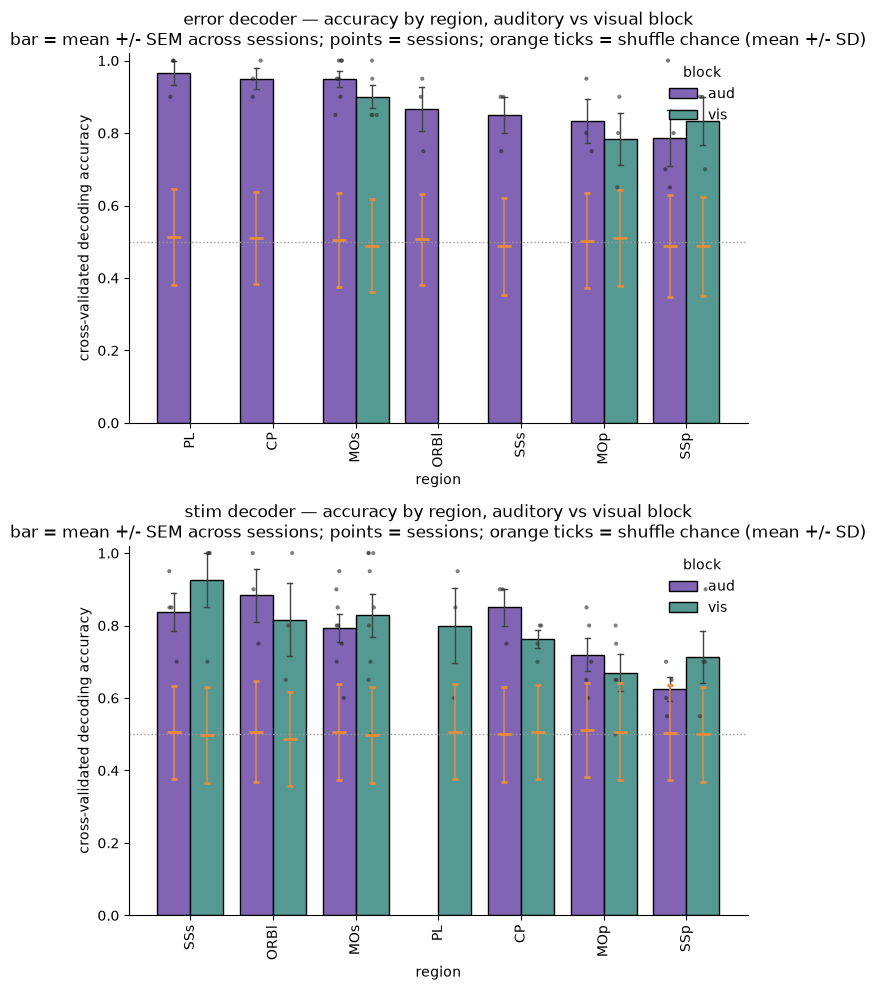

In [ ]:
# Mean decoding accuracy per region, auditory vs visual block (mean +/- SEM
# across sessions, with individual session points). One row per decoder family.
# BLOCK_PAL / BLOCK_ORDER come from the shared colour-scheme cell.

fig, axes = plt.subplots(2, 1, figsize=(max(7, 0.55 * plot_df.region.nunique()), 10))

for ax, family in zip(axes, ['error', 'stim']):
    d = plot_df[plot_df.family == family]
    order = (d.groupby('region')[acc_col].mean()
             .sort_values(ascending=False).index.tolist())

    sns.barplot(data=d, x='region', y=acc_col, hue='block', order=order,
                hue_order=BLOCK_ORDER, palette=BLOCK_PAL, edgecolor='black',
                errorbar='se', capsize=0.12, err_kws={'linewidth': 1.0}, ax=ax)
    sns.stripplot(data=d, x='region', y=acc_col, hue='block', order=order,
                  hue_order=BLOCK_ORDER, dodge=True, color='0.2', size=3,
                  jitter=0.12, alpha=0.6, legend=False, ax=ax)

    # per-region, per-block shuffle chance (mean +/- SD of the null), placed on
    # the dodged bar centres
    for xi, region in enumerate(order):
        for sign, blk in zip((-0.2, 0.2), BLOCK_ORDER):
            sub = d[(d.region == region) & (d.block == blk)]
            if len(sub):
                ax.errorbar(xi + sign, sub['chance'].mean(),
                            yerr=sub['chance_std'].mean(), fmt='_', color=C_ORANGE,
                            markersize=10, markeredgewidth=2, elinewidth=1.1,
                            capsize=2, zorder=5)

    ax.axhline(0.5, ls=':', color='0.6', linewidth=1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('region')
    ax.set_ylabel('cross-validated decoding accuracy')
    ax.set_title(f'{family} decoder — accuracy by region, auditory vs visual block\n'
                 'bar = mean +/- SEM across sessions; points = sessions; '
                 'orange ticks = shuffle chance (mean +/- SD)')
    ax.tick_params(axis='x', rotation=90)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='block', loc='upper right', frameon=False)
    sns.despine(ax=ax)

fig.tight_layout()
plt.show()


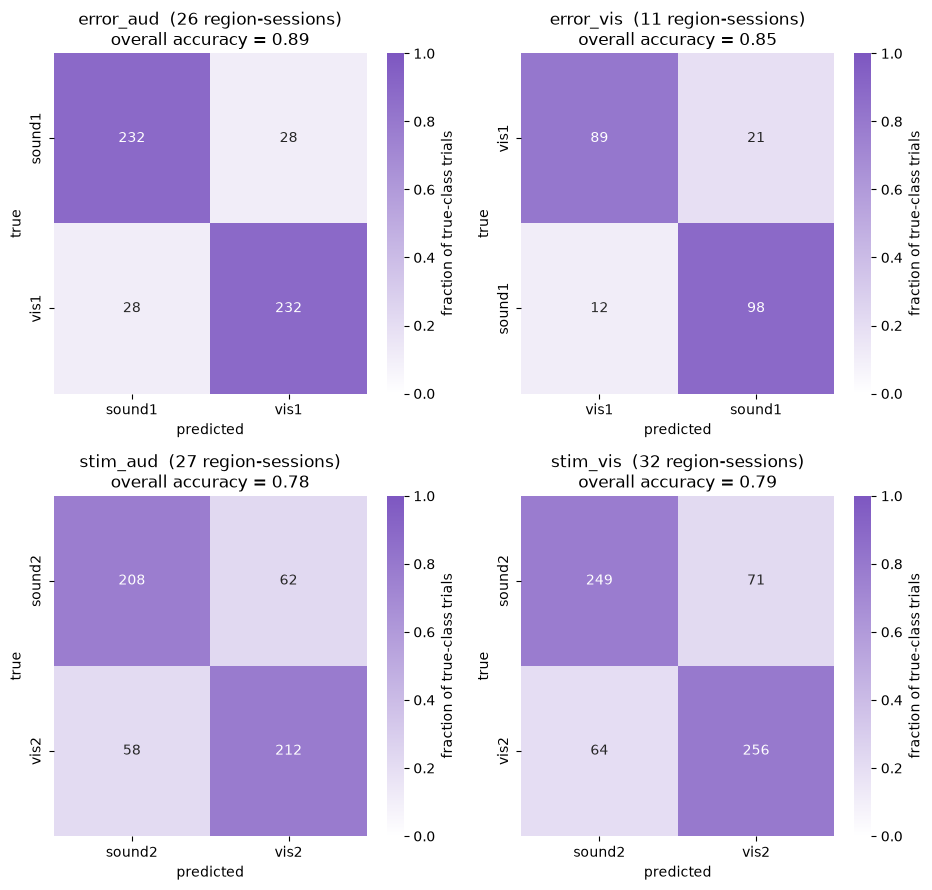

In [ ]:
# Pooled confusion matrix for each of the four decoders (cross-validated
# predictions summed across all ok region-sessions, then row-normalised).
fig, axes = plt.subplots(2, 2, figsize=(9.5, 9))

for ax, name in zip(axes.ravel(), DECODERS):
    g = ok_all[ok_all.decoder == name]
    if not len(g):
        ax.set_visible(False)
        continue
    labels = g['confusion_labels'].iloc[0]
    conf_total = np.sum(np.stack(g['confusion_matrix'].values), axis=0)
    conf_frac = conf_total / conf_total.sum(axis=1, keepdims=True)
    sns.heatmap(conf_frac, annot=conf_total, fmt='d', cmap=SEQ_CMAP,
                vmin=0, vmax=1, xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'fraction of true-class trials'}, ax=ax)
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.set_title(f'{name}  ({len(g)} region-sessions)\n'
                 f'overall accuracy = {np.diag(conf_total).sum() / conf_total.sum():.2f}')

fig.tight_layout()
plt.show()


## A conserved hit / false-alarm code? — decoder pooled across both blocks

The four decoders above are each trained *within* one block. This decoder is
trained on **hit vs false-alarm target trials pooled across the auditory and
the visual block**, to ask whether there is a single, block-invariant neural
code for the behavioural outcome (lick-to-go vs lick-to-nogo) that generalises
regardless of which modality is currently rewarded.

* classes are the **outcome** (`is_hit` vs `is_false_alarm`) on target trials,
  not the stimulus — so `sound1` and `vis1` appear in *both* classes,
* trials are **balanced by block**: each of the four block × outcome cells
  (aud-hit, vis-hit, aud-FA, vis-FA) contributes the same number of trials, so
  block cannot be used as a shortcut,
* run on the regions kept for *both* per-block error decoders
  (`keep['error_aud'] ∩ keep['error_vis']`), on the same 50-unit default-QC
  subsample and the same decode window as Pass 2,
* chance is the label-shuffle null (`N_PERM` permutations), feature importance
  the same repeated-split `weight_stability` as the other decoders.

In [ ]:
# --- Pooled hit vs false-alarm decoder (both blocks, block-balanced) --------
from module import _repeated_split_importance
from sklearn.model_selection import cross_val_score, cross_val_predict, permutation_test_score

POOLED_MIN_PER_CELL = 8       # min trials in each block x outcome cell
POOLED_SEED = 0

pooled_keep = sorted(set(keep['error_aud']) & set(keep['error_vis']))
pooled_todo = scan[scan.meets_error_aud & scan.meets_error_vis
                   & scan.region.isin(pooled_keep)]
print(f"pooled decoder: {len(pooled_todo)} region-sessions "
      f"({pooled_todo.mouse_id.nunique()} mice, "
      f"regions {sorted(pooled_todo.region.unique())})")

_n_bins = len(DECODE_BIN_EDGES) - 1
_win_start = WINDOW_BIN_SLICE.start or 0
_win_stop = WINDOW_BIN_SLICE.stop if WINDOW_BIN_SLICE.stop is not None else _n_bins
_win_dur = float(DECODE_BIN_EDGES[_win_stop] - DECODE_BIN_EDGES[_win_start])
POOLED_CLASSES = np.array(['hit', 'false_alarm'])

pooled_rows = []
for (subject_id, region), _ in tqdm(list(pooled_todo.groupby(['mouse_id', 'region'])),
                                    desc="pooled", unit="region-session"):
    _nwb, units_s, trials_s = nwb_cache[subject_id]

    # units: default QC in region, same 50-unit subsample as the other decoders
    region_units = units_s[units_s.default_qc & (units_s.structure == region)]
    if len(region_units) < MIN_UNITS:
        continue
    u_rng = np.random.default_rng(POOLED_SEED)
    u_pick = np.sort(u_rng.choice(len(region_units), size=50, replace=False))
    region_units = region_units.iloc[u_pick]

    # trials: hit / FA target trials in each block, then balance the 4 cells
    onset = trials_s.stim_start_time.to_numpy()
    is_tgt = trials_s.is_target.to_numpy()
    blk = trials_s.rewarded_modality.to_numpy()
    is_hit = trials_s.is_hit.to_numpy()
    is_fa = trials_s.is_false_alarm.to_numpy()
    cells = {
        ('hit', 'aud'): np.flatnonzero(is_tgt & is_hit & (blk == 'aud')),
        ('hit', 'vis'): np.flatnonzero(is_tgt & is_hit & (blk == 'vis')),
        ('false_alarm', 'aud'): np.flatnonzero(is_tgt & is_fa & (blk == 'aud')),
        ('false_alarm', 'vis'): np.flatnonzero(is_tgt & is_fa & (blk == 'vis')),
    }
    n_per_cell = min(len(v) for v in cells.values())
    if n_per_cell < POOLED_MIN_PER_CELL:
        continue
    t_rng = np.random.default_rng(POOLED_SEED)
    sel_idx, sel_label = [], []
    for (outcome, _b), idx in cells.items():
        sel_idx.append(t_rng.choice(idx, size=n_per_cell, replace=False))
        sel_label += [outcome] * n_per_cell
    sel_idx = np.concatenate(sel_idx)
    label_array = np.array(sel_label)
    stim_times = onset[sel_idx]

    # population spike-count matrix (trials x neurons) over the decode window
    tensor = np.zeros((len(region_units), len(stim_times), _n_bins))
    for row, spk in enumerate(region_units.spike_times.values):
        tensor[row] = get_binned_triggered_spike_counts_fast(
            spk, stim_times, DECODE_BIN_EDGES)
    count_array = np.sum(tensor[:, :, WINDOW_BIN_SLICE], axis=2).T
    rate_array = count_array / _win_dur

    x_tr, x_te, y_tr, y_te = train_test_split(
        count_array, label_array, random_state=POOLED_SEED, stratify=label_array)
    svc = LinearSVC(max_iter=5000, random_state=POOLED_SEED).fit(x_tr, y_tr)
    cv_scores = cross_val_score(
        LinearSVC(max_iter=5000, random_state=POOLED_SEED),
        count_array, label_array, cv=5)
    cv_pred = cross_val_predict(
        LinearSVC(max_iter=5000, random_state=POOLED_SEED),
        count_array, label_array, cv=5)
    _, null_scores, perm_p = permutation_test_score(
        LinearSVC(max_iter=5000, random_state=POOLED_SEED),
        count_array, label_array, cv=5, n_permutations=N_PERM,
        random_state=POOLED_SEED, n_jobs=-1)
    imp = _repeated_split_importance(
        count_array, rate_array, label_array,
        rew_stim='hit', unrew_stim='false_alarm',
        n_repeats=N_IMPORTANCE_REPEATS, top_frac=IMPORTANCE_TOP_FRAC,
        test_size=0.25, max_iter=5000, random_state=POOLED_SEED)

    pooled_rows.append(dict(
        mouse_id=subject_id, region=region, block='both',
        decoder='error_pooled', family='error_pooled', status='ok',
        n_units=len(region_units), n_trials=len(label_array),
        n_per_cell=int(n_per_cell),
        split_accuracy=svc.score(x_te, y_te),
        cv_accuracy_mean=float(cv_scores.mean()), cv_accuracy_folds=cv_scores,
        chance=float(null_scores.mean()),
        chance_std=float(null_scores.std(ddof=1)), chance_p=float(perm_p),
        null_accuracy=null_scores,
        confusion_matrix=confusion_matrix(label_array, cv_pred, labels=POOLED_CLASSES),
        confusion_labels=list(POOLED_CLASSES),
        unit_ids=region_units.index.to_numpy(), **imp))
    tqdm.write(f"  {subject_id} {region:<5} cv {cv_scores.mean():.2f} "
               f"(chance {null_scores.mean():.2f} +/- {null_scores.std(ddof=1):.2f}, "
               f"p {perm_p:.3f}; {n_per_cell}/cell)")

pooled_results = pd.DataFrame(pooled_rows)
pooled_ok = pooled_results[pooled_results.status == 'ok'].copy()

# per-neuron importance table for the pooled decoder (same shape as unit_importance)
pooled_unit_importance = pd.DataFrame([
    dict(decoder='error_pooled', family='error_pooled', block='both',
         mouse_id=r.mouse_id, region=r.region, unit_id=int(uid),
         weight_stability=float(r.weight_stability[j]),
         weight_abs_mean=float(r.weight_abs_mean[j]),
         single_unit_stat=float(r.single_unit_stat[j]),
         n_stat_reps=int(r.single_unit_stat_n_reps[j]))
    for r in pooled_ok.itertuples() for j, uid in enumerate(r.unit_ids)
])
print(f"\npooled decoder: {len(pooled_ok)} region-sessions, "
      f"{len(pooled_unit_importance)} unit rows")
pooled_ok[['mouse_id', 'region', 'n_per_cell', 'n_trials',
           'cv_accuracy_mean', 'chance', 'chance_p']]


pooled decoder: 11 region-sessions (6 mice, regions ['MOp', 'MOs', 'SSp'])


NameError: name 'DECODE_BIN_EDGES' is not defined

In [ ]:
# Pooled hit-vs-FA decoder: accuracy by region + pooled confusion matrix.
if len(pooled_ok):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                             gridspec_kw={'width_ratios': [1.5, 1]})

    d = pooled_ok.dropna(subset=['cv_accuracy_mean'])
    order = (d.groupby('region')['cv_accuracy_mean'].mean()
             .sort_values(ascending=False).index.tolist())
    sns.barplot(data=d, x='region', y='cv_accuracy_mean', order=order,
                color=C_PURPLE, edgecolor='black', errorbar='se',
                capsize=0.15, err_kws={'linewidth': 1.0}, ax=axes[0])
    sns.stripplot(data=d, x='region', y='cv_accuracy_mean', order=order,
                  color='0.2', size=4, jitter=0.15, alpha=0.7, ax=axes[0])
    for xi, region in enumerate(order):
        sub = d[d.region == region]
        axes[0].errorbar(xi, sub['chance'].mean(), yerr=sub['chance_std'].mean(),
                         fmt='_', color=C_ORANGE, markersize=12, markeredgewidth=2,
                         elinewidth=1.1, capsize=3, zorder=5)
    axes[0].axhline(0.5, ls=':', color='0.6', linewidth=1)
    axes[0].set_ylim(0, 1.02)
    axes[0].set_xlabel('region')
    axes[0].set_ylabel('cross-validated accuracy')
    axes[0].set_title('pooled hit vs false-alarm decoder (both blocks)\n'
                      'bar = mean +/- SEM across sessions; points = sessions; '
                      'orange = shuffle chance')
    axes[0].tick_params(axis='x', rotation=90)
    sns.despine(ax=axes[0])

    conf = np.sum(np.stack(pooled_ok['confusion_matrix'].values), axis=0)
    conf_frac = conf / conf.sum(axis=1, keepdims=True)
    labels = pooled_ok['confusion_labels'].iloc[0]
    sns.heatmap(conf_frac, annot=conf, fmt='d', cmap=SEQ_CMAP, vmin=0, vmax=1,
                xticklabels=labels, yticklabels=labels, ax=axes[1],
                cbar_kws={'label': 'fraction of true-class trials'})
    axes[1].set_xlabel('predicted')
    axes[1].set_ylabel('true')
    axes[1].set_title(f'pooled confusion ({len(pooled_ok)} region-sessions)\n'
                      f'overall accuracy = {np.diag(conf).sum() / conf.sum():.2f}')

    fig.tight_layout()
    plt.show()
else:
    print("no region-session met the pooled-decoder criterion")


## Which neurons carry each decoder (feature importance)

For every decoder (all four: error / stim × aud / vis) each region-session is
fit `N_IMPORTANCE_REPEATS` times on independent stratified train/test splits.
In each repeat `r` we keep the weight vector `w_r`, score `accuracy_r` on the
held-out trials, and flag the top `IMPORTANCE_TOP_FRAC` of neurons by `|w_r|`
as "important".

Two per-neuron quantities come out of this:

* **`weight_stability`** — the fraction of repeats in which the neuron was
  flagged (`weight_abs_mean`, the mean `|w_r|` across repeats, is the
  continuous version).
* **`single_unit_stat`** — the circularity-safe firing-property estimate,
  computed **only on the held-out trials** of the repeats in which the neuron
  was both flagged and had test trials of both classes. For the **error**
  decoders it is `mean rate on hit trials − mean rate on false-alarm trials`;
  for the **stim** decoders it is `mean rate on sound2 − mean rate on vis2`.
  Selection (flagging) and measurement never use the same trials, so it is not
  inflated by selection bias.

Both quantities are collected into the `unit_importance` table below, which
feeds the error-exclusive comparison in the next section.


In [ ]:
# Unpack the per-neuron importance arrays into one long table (one row per unit
# per region-session per decoder).
def unit_importance_table(ok_rows):
    out = []
    for _, r in ok_rows.iterrows():
        for j, uid in enumerate(r['unit_ids']):
            out.append(dict(
                decoder=r['decoder'],
                family=r['family'],
                block=r['block'],
                mouse_id=r['mouse_id'],
                region=r['region'],
                unit_id=int(uid),
                weight_stability=float(r['weight_stability'][j]),
                weight_abs_mean=float(r['weight_abs_mean'][j]),
                single_unit_stat=float(r['single_unit_stat'][j]),
                n_stat_reps=int(r['single_unit_stat_n_reps'][j]),
            ))
    return pd.DataFrame(out)

unit_importance = unit_importance_table(ok_all)

n_flag_frac = (ok_all['n_flagged_per_rep'].iloc[0]
               / len(ok_all['weight_stability'].iloc[0]))
for name, g in unit_importance.groupby('decoder'):
    n_rs = g.groupby(['mouse_id', 'region']).ngroups
    print(f"{name:<10}: {len(g)} units across {n_rs} region-sessions")
print(f"~{n_flag_frac:.0%} of neurons flagged per repeat (chance stability)")

unit_importance.sort_values('weight_stability', ascending=False).head(15)


error_aud : 1300 units across 26 region-sessions
error_vis : 550 units across 11 region-sessions
stim_aud  : 1350 units across 27 region-sessions
stim_vis  : 1600 units across 32 region-sessions
~10% of neurons flagged per repeat (chance stability)


,decoder,family,block,mouse_id,region,unit_id,weight_stability,weight_abs_mean,single_unit_stat,n_stat_reps
4741,stim_vis,stim,vis,759434,MOs,2211,1.0,0.204553,5.305556,10
4738,stim_vis,stim,vis,759434,MOs,2153,1.0,0.262619,1.972222,10
4737,stim_vis,stim,vis,759434,MOs,2143,1.0,0.177564,1.527778,10
1290,error_aud,error,aud,759434,SSp,862,1.0,0.151022,-6.444444,10
2736,stim_aud,stim,aud,715710,SSs,480,1.0,0.145096,9.333333,10
1257,error_aud,error,aud,759434,SSp,181,1.0,0.149174,8.138889,10
2851,stim_aud,stim,aud,742903,CP,2,1.0,0.103918,0.555556,10
671,error_aud,error,aud,715710,ORBl,1591,1.0,0.095846,13.777778,10
2779,stim_aud,stim,aud,741137,MOp,1896,1.0,0.113034,-7.805556,10
4552,stim_vis,stim,vis,743199,MOs,1110,1.0,0.129112,0.833333,10


## Error-exclusive neurons: error decoder vs stim decoder, within each block

Within a block the error and stim decoders are run on the same region-sessions
and the same 50-unit subsample, so each unit has two `weight_stability`
scores:

* **error decoder** — target hit vs distractor false alarm (stimulus identity
  *and* lick / error signal),
* **stim decoder** — sound2 vs vis2 on correct-reject trials (stimulus
  identity only, lick withheld).

A unit that is a stable feature of the error decoder but *not* of the stim
decoder carries the lick / error signal rather than stimulus identity. We flag
those as **error-exclusive**: `stability(error) >= HIGH` and
`stability(stim) <= LOW`. This is computed separately for the auditory and the
visual block, and then compared across the two blocks.

[aud] 1050 units decoded by BOTH families (6 regions, 8 mice)  |  error-exclusive 36  stim-exclusive 29  shared-stable 7
[vis] 550 units decoded by BOTH families (3 regions, 6 mice)  |  error-exclusive 14  stim-exclusive 9  shared-stable 4


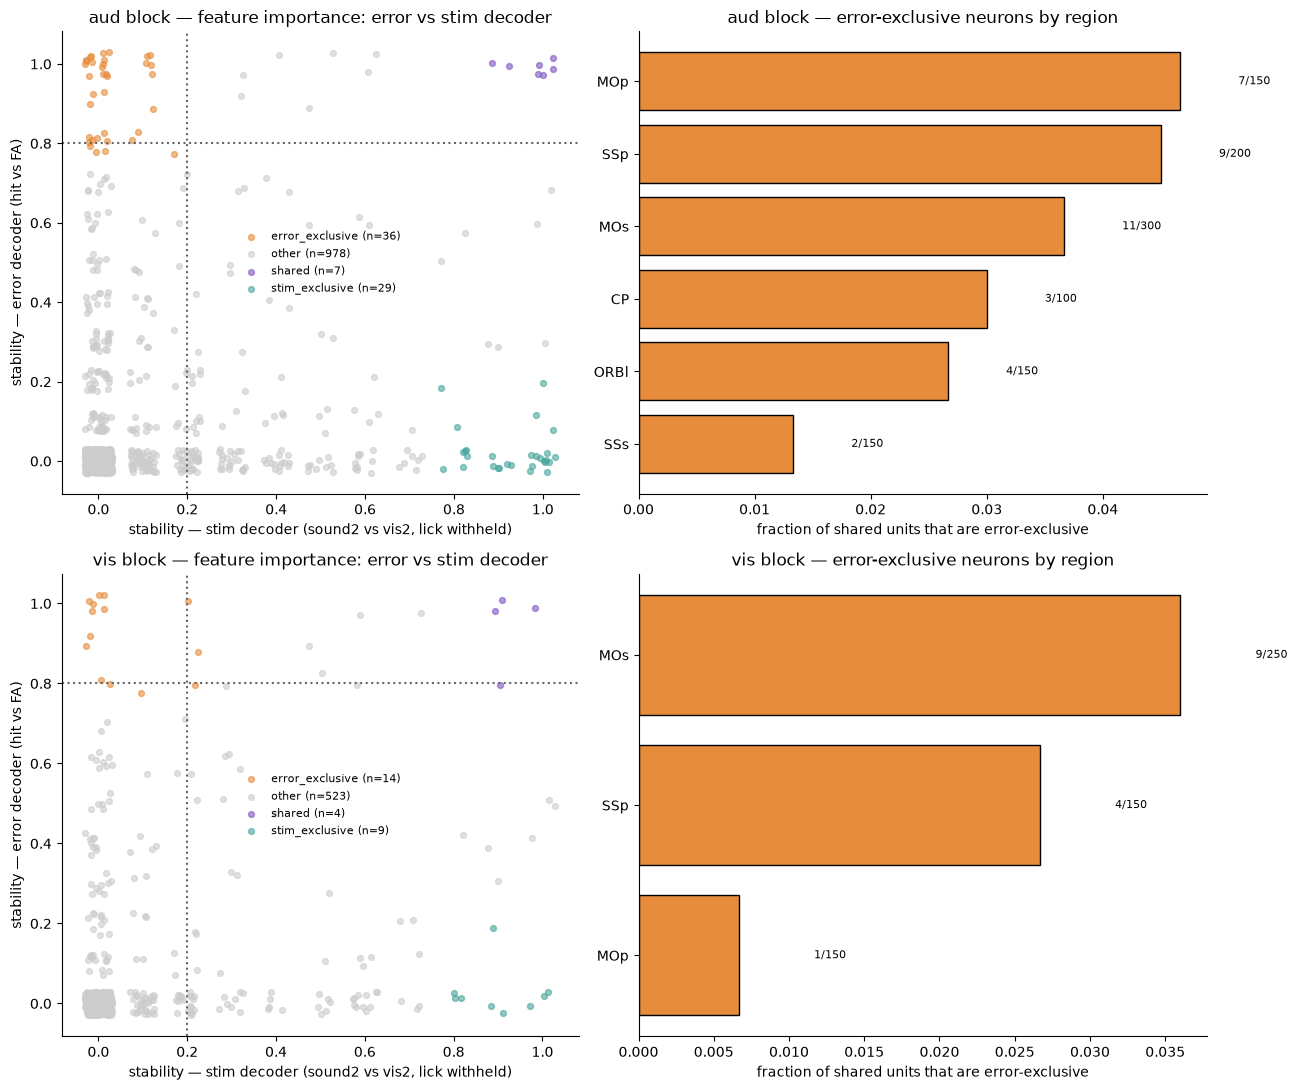

In [ ]:
# Match units across the error and stim decoders on (mouse, region, unit_id),
# separately within each block.
HIGH = 0.8      # "stable feature" threshold
LOW = 0.2       # "not a feature" threshold

def compare_families(block):
    e = unit_importance[(unit_importance.family == 'error')
                        & (unit_importance.block == block)]
    s = unit_importance[(unit_importance.family == 'stim')
                        & (unit_importance.block == block)]
    c = e.merge(s, on=['mouse_id', 'region', 'unit_id'],
                suffixes=('_error', '_stim'))
    c['block'] = block
    c['error_exclusive'] = ((c.weight_stability_error >= HIGH)
                            & (c.weight_stability_stim <= LOW))
    c['stim_exclusive'] = ((c.weight_stability_stim >= HIGH)
                           & (c.weight_stability_error <= LOW))
    c['shared'] = ((c.weight_stability_error >= HIGH)
                   & (c.weight_stability_stim >= HIGH))
    c['group'] = np.select(
        [c.error_exclusive, c.stim_exclusive, c.shared],
        ['error_exclusive', 'stim_exclusive', 'shared'], default='other')
    return c

cmp = pd.concat([compare_families('aud'), compare_families('vis')],
                ignore_index=True)

for blk in BLOCK_ORDER:
    b = cmp[cmp.block == blk]
    print(f"[{blk}] {len(b)} units decoded by BOTH families "
          f"({b.region.nunique()} regions, {b.mouse_id.nunique()} mice)  |  "
          f"error-exclusive {int(b.error_exclusive.sum())}  "
          f"stim-exclusive {int(b.stim_exclusive.sum())}  "
          f"shared-stable {int(b.shared.sum())}")

# GROUP_PAL comes from the shared colour-scheme cell
jit = lambda v: v + np.random.uniform(-0.03, 0.03, len(v))

fig, axes = plt.subplots(2, 2, figsize=(13, 11),
                         gridspec_kw={'width_ratios': [1, 1.1]})

for row, blk in enumerate(BLOCK_ORDER):
    b = cmp[cmp.block == blk]

    # left: stability(stim) vs stability(error)
    ax = axes[row, 0]
    for g, sub in b.groupby('group'):
        ax.scatter(jit(sub.weight_stability_stim), jit(sub.weight_stability_error),
                   s=18, alpha=0.6, color=GROUP_PAL[g], label=f'{g} (n={len(sub)})')
    ax.axvline(LOW, ls=':', color='0.4')
    ax.axhline(HIGH, ls=':', color='0.4')
    ax.set_xlabel('stability — stim decoder (sound2 vs vis2, lick withheld)')
    ax.set_ylabel('stability — error decoder (hit vs FA)')
    ax.set_title(f'{blk} block — feature importance: error vs stim decoder')
    ax.legend(frameon=False, fontsize=8)
    sns.despine(ax=ax)

    # right: error-exclusive fraction per region
    ax = axes[row, 1]
    by_region = (b.groupby('region')
                 .agg(n_both=('unit_id', 'size'),
                      n_error_excl=('error_exclusive', 'sum'))
                 .assign(frac=lambda d: d.n_error_excl / d.n_both)
                 .sort_values('frac', ascending=False))
    ax.barh(by_region.index, by_region.frac, color=C_ORANGE, edgecolor='black')
    for yi, (reg, r) in enumerate(by_region.iterrows()):
        ax.text(r.frac + 0.005, yi, f"{int(r.n_error_excl)}/{int(r.n_both)}",
                va='center', fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('fraction of shared units that are error-exclusive')
    ax.set_title(f'{blk} block — error-exclusive neurons by region')
    sns.despine(ax=ax)

fig.tight_layout()
plt.show()


In [ ]:
# The error-exclusive neurons in each block, with their held-out firing stats.
#   single_unit_stat_error : held-out (hit - FA)      rate diff (Hz)
#   single_unit_stat_stim  : held-out (sound2 - vis2) rate diff (Hz)
error_exclusive = (
    cmp.loc[cmp.error_exclusive,
            ['block', 'mouse_id', 'region', 'unit_id',
             'weight_stability_error', 'weight_stability_stim',
             'single_unit_stat_error', 'n_stat_reps_error',
             'single_unit_stat_stim', 'n_stat_reps_stim']]
    .sort_values(['block', 'region', 'weight_stability_error'],
                 ascending=[True, True, False])
    .reset_index(drop=True))
print(f"{len(error_exclusive)} error-exclusive units "
      f"(stability_error >= {HIGH}, stability_stim <= {LOW})")

# --- across-block comparison: units tested in BOTH blocks -----------------
# (a unit is tested in both blocks only if its region-session met all four
#  decoders' criteria)
both = cmp[cmp.block == 'aud'].merge(
    cmp[cmp.block == 'vis'], on=['mouse_id', 'region', 'unit_id'],
    suffixes=('_aud', '_vis'))
print(f"\n{len(both)} units decoded in BOTH blocks "
      f"({both.region.nunique()} regions, {both.mouse_id.nunique()} mice)")

# FINAL PLOT: highlight every neuron that carries the ERROR decoder in both
# blocks (weight_stability_error >= HIGH in aud AND vis), regardless of what
# the stim decoder did for that neuron.
both['error_both_blocks'] = ((both.weight_stability_error_aud >= HIGH)
                             & (both.weight_stability_error_vis >= HIGH))
error_decoding_both_blocks = (
    both.loc[both.error_both_blocks,
             ['mouse_id', 'region', 'unit_id',
              'weight_stability_error_aud', 'weight_stability_error_vis',
              'weight_stability_stim_aud', 'weight_stability_stim_vis',
              'single_unit_stat_error_aud', 'single_unit_stat_error_vis']]
    .sort_values(['region', 'mouse_id']).reset_index(drop=True))

n_both = int(both.error_both_blocks.sum())
n_aud_only = int(((both.weight_stability_error_aud >= HIGH)
                  & (both.weight_stability_error_vis < HIGH)).sum())
n_vis_only = int(((both.weight_stability_error_aud < HIGH)
                  & (both.weight_stability_error_vis >= HIGH)).sum())
print(f"error-decoding (stability_error >= {HIGH}) in both blocks: {n_both}  |  "
      f"aud only: {n_aud_only}  |  vis only: {n_vis_only}")

if len(both):
    fig, ax = plt.subplots(figsize=(5.5, 5))
    ax.scatter(jit(both.weight_stability_error_aud.values),
               jit(both.weight_stability_error_vis.values),
               s=20, alpha=0.5, color='0.7', label=f'all units (n={len(both)})')
    hi = both[both.error_both_blocks]
    ax.scatter(jit(hi.weight_stability_error_aud.values),
               jit(hi.weight_stability_error_vis.values),
               s=45, color=C_ORANGE, edgecolor='0.2', linewidth=0.5,
               label=f'error-decoding in both blocks (n={len(hi)})')
    ax.axvline(HIGH, ls=':', color='0.4')
    ax.axhline(HIGH, ls=':', color='0.4')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('error-decoder stability — aud block')
    ax.set_ylabel('error-decoder stability — vis block')
    ax.set_title('error-decoder feature importance across blocks\n'
                 f'orange = stability >= {HIGH} in both blocks (stim decoder ignored)')
    ax.legend(frameon=False, fontsize=8, loc='lower right')
    sns.despine(ax=ax)
    fig.tight_layout()
    plt.show()

error_decoding_both_blocks


## Pulling out the high-feature-importance units

For a chosen decoder and region-session, `qc_units_table` is the subset of that
session's `nwbfile.units.to_dataframe()` that actually fed the decoder — the
default-QC units in the region, after the 50-unit subsample. Its index is the
NWB unit id, and the per-neuron feature-importance quantities
(`weight_stability`, `weight_abs_mean`, `single_unit_stat`) are joined on as
columns, so you can index straight into it:

```python
high_fi_units = qc_units_table[qc_units_table.weight_stability >= HIGH_FI_STABILITY]
high_fi_ids   = high_fi_units.index          # NWB unit ids to carry forward
```

`qc_units_table_for(decoder, mouse_id, region)` builds the same table for any
region-session; `all_unit_importance` is the long table across every decoder
(the four per-block decoders plus `error_pooled`).

In [ ]:
# Unit indices with high feature importance -------------------------------
HIGH_FI_STABILITY = HIGH        # weight_stability >= this "carries the decoder"

# every decoder's per-neuron importance in one long table
all_unit_importance = pd.concat(
    [unit_importance, pooled_unit_importance], ignore_index=True) \
    if len(pooled_unit_importance) else unit_importance.copy()

# every decoder's row-level result (has unit_ids + the importance arrays)
_all_ok = pd.concat([ok_all, pooled_ok], ignore_index=True) \
    if len(pooled_ok) else ok_all.copy()


def qc_units_table_for(decoder, mouse_id, region):
    """Subset of this session's units.to_dataframe() that fed `decoder` in this
    region-session, indexed by NWB unit id, with the feature-importance columns
    (weight_stability, weight_abs_mean, single_unit_stat) joined on."""
    r = _all_ok[(_all_ok.decoder == decoder) & (_all_ok.mouse_id == mouse_id)
                & (_all_ok.region == region)]
    if not len(r):
        raise KeyError(f"no {decoder} result for mouse {mouse_id}, region {region}")
    r = r.iloc[0]
    units_df = nwb_cache[mouse_id][1]                 # full units.to_dataframe()
    tbl = units_df.loc[r['unit_ids']].copy()
    tbl['weight_stability'] = np.asarray(r['weight_stability'])
    tbl['weight_abs_mean'] = np.asarray(r['weight_abs_mean'])
    tbl['single_unit_stat'] = np.asarray(r['single_unit_stat'])
    tbl['decoder'] = decoder
    return tbl


# --- example: pick the region-session with the most high-importance units ---
FI_DECODER = 'error_aud'
_rank = (all_unit_importance[all_unit_importance.decoder == FI_DECODER]
         .assign(hi=lambda d: d.weight_stability >= HIGH_FI_STABILITY)
         .groupby(['mouse_id', 'region']).hi.sum()
         .sort_values(ascending=False))
FI_MOUSE, FI_REGION = _rank.index[0]
print(f"example -> decoder {FI_DECODER}, mouse {FI_MOUSE}, region {FI_REGION}")

qc_units_table = qc_units_table_for(FI_DECODER, FI_MOUSE, FI_REGION)

# index straight into it to get the high-feature-importance units
high_fi_units = qc_units_table[qc_units_table.weight_stability >= HIGH_FI_STABILITY]
high_fi_ids = high_fi_units.index                     # NWB unit ids to carry forward

print(f"{len(qc_units_table)} QC units fed the decoder; "
      f"{len(high_fi_ids)} have weight_stability >= {HIGH_FI_STABILITY}")
print("high-importance unit ids:", list(high_fi_ids))

high_fi_units[['structure', 'weight_stability', 'weight_abs_mean',
               'single_unit_stat', 'firing_rate', 'presence_ratio',
               'isi_violations_ratio']].sort_values('weight_stability',
                                                    ascending=False)


NameError: name 'pooled_unit_importance' is not defined

In [ ]:
# =====================================================================
# SAVE RESULTS  --  written to /scratch
# ---------------------------------------------------------------------
# This writes to /scratch, which Code Ocean does NOT keep once the
# capsule stops (nor are the home directory or /code). Move anything
# worth keeping to ./results (a symlink to /results) before shutting
# the capsule down, or point run_dir back at /results.
#
# Written into /scratch/decode_across_mice_regions/<timestamp>/ :
#   results_raw.pkl        full Pass 2 DataFrame `results` (one row per
#                          region-session) WITH every numpy array column
#                          (null_accuracy, coef_weights, weight_stability,
#                          weight_abs_mean, single_unit_stat, unit_ids,
#                          confusion_matrix, cv_accuracy_folds, ...).
#                          Reload with pandas.read_pickle(...).
#   pass2_results.csv      the same table, array columns dropped (flat view)
#   pooled_results_raw.pkl / pooled_results.csv
#                          the pooled hit-vs-FA (both-blocks) decoder
#   session_metadata.csv   `df`
#   pass1_scan.csv         `scan`  (per mouse x region criterion)
#   unit_importance.csv    `all_unit_importance`  (one row per unit/decoder,
#                          incl. error_pooled)
#   family_comparison.csv  `cmp`  (error vs stim decoder, per unit)
#   error_exclusive.csv    `error_exclusive`
#   error_decoding_both_blocks.csv   units carrying the error decoder in both
#                                    blocks (final-plot highlight)
#   failed_sessions.csv    sessions the datacube mount would not serve
#   run_params.json        window, N_PERM, N_IMPORTANCE_REPEATS, thresholds, counts
#
# Figures are not saved here; add fig.savefig(run_dir / "name.png") if wanted.
# =====================================================================
import json, datetime, pathlib

_ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = pathlib.Path("/scratch/decode_across_mice_regions") / _ts
run_dir.mkdir(parents=True, exist_ok=True)

def _dump_csv(name, obj):
    if obj is None:
        return
    frame = obj if isinstance(obj, pd.DataFrame) else pd.DataFrame(obj)
    frame.to_csv(run_dir / name, index=False)
    print(f"  {name:<32} {len(frame):>5} rows")

def _flat(frame):
    arr_cols = [c for c in frame.columns
                if frame[c].map(lambda v: isinstance(v, (np.ndarray, list))).any()]
    return frame.drop(columns=arr_cols)

# --- full raw output (the expensive result), arrays preserved ---
results.to_pickle(run_dir / "results_raw.pkl")
print(f"  {'results_raw.pkl':<32} {len(results):>5} region-sessions  (pickle)")
_dump_csv("pass2_results.csv", _flat(results))

if len(pooled_results):
    pooled_results.to_pickle(run_dir / "pooled_results_raw.pkl")
    print(f"  {'pooled_results_raw.pkl':<32} {len(pooled_results):>5} region-sessions  (pickle)")
    _dump_csv("pooled_results.csv", _flat(pooled_results))

_dump_csv("session_metadata.csv", df)
_dump_csv("pass1_scan.csv", scan)
_dump_csv("unit_importance.csv", all_unit_importance)
_dump_csv("family_comparison.csv", cmp)
_dump_csv("error_exclusive.csv", error_exclusive)
_dump_csv("error_decoding_both_blocks.csv", error_decoding_both_blocks)
_dump_csv("failed_sessions.csv", pd.DataFrame(failed_sessions))

with open(run_dir / "run_params.json", "w") as _fh:
    json.dump(dict(
        run_local_time=_ts,
        DECODE_WINDOW_S=list(DECODE_WINDOW_S),
        WINDOW_BIN_SLICE=[WINDOW_BIN_SLICE.start, WINDOW_BIN_SLICE.stop],
        N_PERM=N_PERM,
        N_IMPORTANCE_REPEATS=N_IMPORTANCE_REPEATS,
        IMPORTANCE_TOP_FRAC=IMPORTANCE_TOP_FRAC,
        MIN_UNITS=MIN_UNITS,
        MIN_TRIALS_PER_CLASS=MIN_TRIALS_PER_CLASS,
        MIN_SESSIONS=MIN_SESSIONS,
        POOLED_MIN_PER_CELL=POOLED_MIN_PER_CELL,
        HIGH=HIGH, LOW=LOW,
        N_LOAD_RETRIES=N_LOAD_RETRIES,
        n_region_sessions=int(len(results)),
        n_ok=int((results.status == "ok").sum()),
        n_pooled_ok=int(len(pooled_ok)),
        n_failed_sessions=int(len(failed_sessions)),
    ), _fh, indent=2)
print(f"  {'run_params.json':<32}")

print(f"\nsaved to: {run_dir}")
print("(under /scratch -> NOT kept after the capsule shuts down; "
      "copy to ./results to persist)")
